# Legendre truncation

#### Import general modules

mpi4py is always required when using these tools. Numpy is always good to have if any manipulation is to be done.

In [1]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

import os
os.environ["PYSEMTOOLS_DEBUG"] = 'false'
os.environ["PYSEMTOOLS_HIDE_LOG"] = 'false'

#### Import modules from pysemtools

In this case we will import all the data types that we currently support, as well as io functions that are required to populate them.

In [2]:
# Data types
from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.coef import Coef
from pysemtools.datatypes.field import Field, FieldRegistry

# Readers
from pysemtools.io.ppymech.neksuite import preadnek, pynekread

# Writers
from pysemtools.io.ppymech.neksuite import pwritenek, pynekwrite

fname = '../../data/mixlay0.f00001'

## Read the data

In [3]:
# Read the data
msh = Mesh(comm, create_connectivity=False)
fld = FieldRegistry(comm)
pynekread(fname, comm, data_dtype=np.double, msh = msh, fld = fld)
 
# Get the coefficients
coef = Coef(msh=msh, comm=comm)

2026-08-04 21:01:13,654  pynekread             INFO      Reading file: ../../data/mixlay0.f00001
2026-08-04 21:01:13,666  Mesh                  INFO      Mesh object initialized from coordinates with type: float64 - Elapsed time: 0.002942822999999999s
2026-08-04 21:01:13,672  Field                 INFO      Field registry updated with: ['u', 'v', 'p', 't', 's0', 's1'] - dtype: float64
2026-08-04 21:01:13,676  pynekread             INFO      File successfully read - Elapsed time: 0.02208063s
2026-08-04 21:01:13,683  Coef                  INFO      Coef object initialized - dtype: float64 - Elapsed time: 0.006256168999999999s


## Compress the data with GPR

### Initialize the Direct sampler

In [4]:
from pysemtools.compression.legendre_truncation import DiscreetLegendreTruncation

# Initialize a sampler with numpy (default)
dlt = DiscreetLegendreTruncation(comm=comm, msh=msh, coef=coef)

2026-08-04 21:01:14,611  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object


### Sample the data

In [5]:
# Select the options
target_error = 1e-4
dlt.log.tic()
dlt.sample_field(field=fld.registry["u"], field_name="u", compression_method="fixed_error", target_error=target_error)
dlt.log.toc()

2026-08-04 21:01:14,623  DirectSampler         INFO      Sampling the field with options: covariance_method: {covariance_method}, compression_method: {compression_method}
2026-08-04 21:01:14,624  DirectSampler         INFO      Transforming the field into to legendre space
2026-08-04 21:01:14,627  DirectSampler         INFO      Sampling the field using the fixed error method. using settings: {'method': 'fixed_error', 'target_error': 0.0001, 'max_samples_per_it': 1}
2026-08-04 21:01:14,632  DirectSampler         INFO      Sampled_field saved in field uncompressed_data["u"]["field"]
2026-08-04 21:01:14,633  DirectSampler         INFO      Elapsed time: 0.009899059000000099s


### Encode it

In [6]:
dlt.compress_samples(lossless_compressor="bzip2")

2026-08-04 21:01:14,643  DirectSampler         INFO      Compressing the data using the lossless compressor: bzip2
2026-08-04 21:01:14,645  DirectSampler         INFO      Compressing data in uncompressed_data
2026-08-04 21:01:14,646  DirectSampler         INFO      Compressing data for field ["u"]:
2026-08-04 21:01:14,646  DirectSampler         INFO      Compressing ["field"] for field ["u"]


### Write it out

In [7]:
dlt.write_compressed_samples(comm=comm, filename="test")

2026-08-04 21:01:14,666  DirectSampler         INFO      Parallel HDF5 not available; creating folder to store rank files.


## Decompress the data

### Read the data

In [8]:
dlt_read = DiscreetLegendreTruncation(comm, filename="test")

2026-08-04 21:01:14,685  DirectSampler         INFO      Initializing the DirectSampler from file: test


### Reconstruct the data from the samples

In [9]:
u_np= dlt_read.reconstruct_field(field_name="u")

## Visualize the data

In [10]:
# General settings

u = fld.registry["u"]
u_levels = np.linspace(np.min(u), np.max(u), 100)
err_levels = np.linspace(0, 0.5, 100)

### Numpy

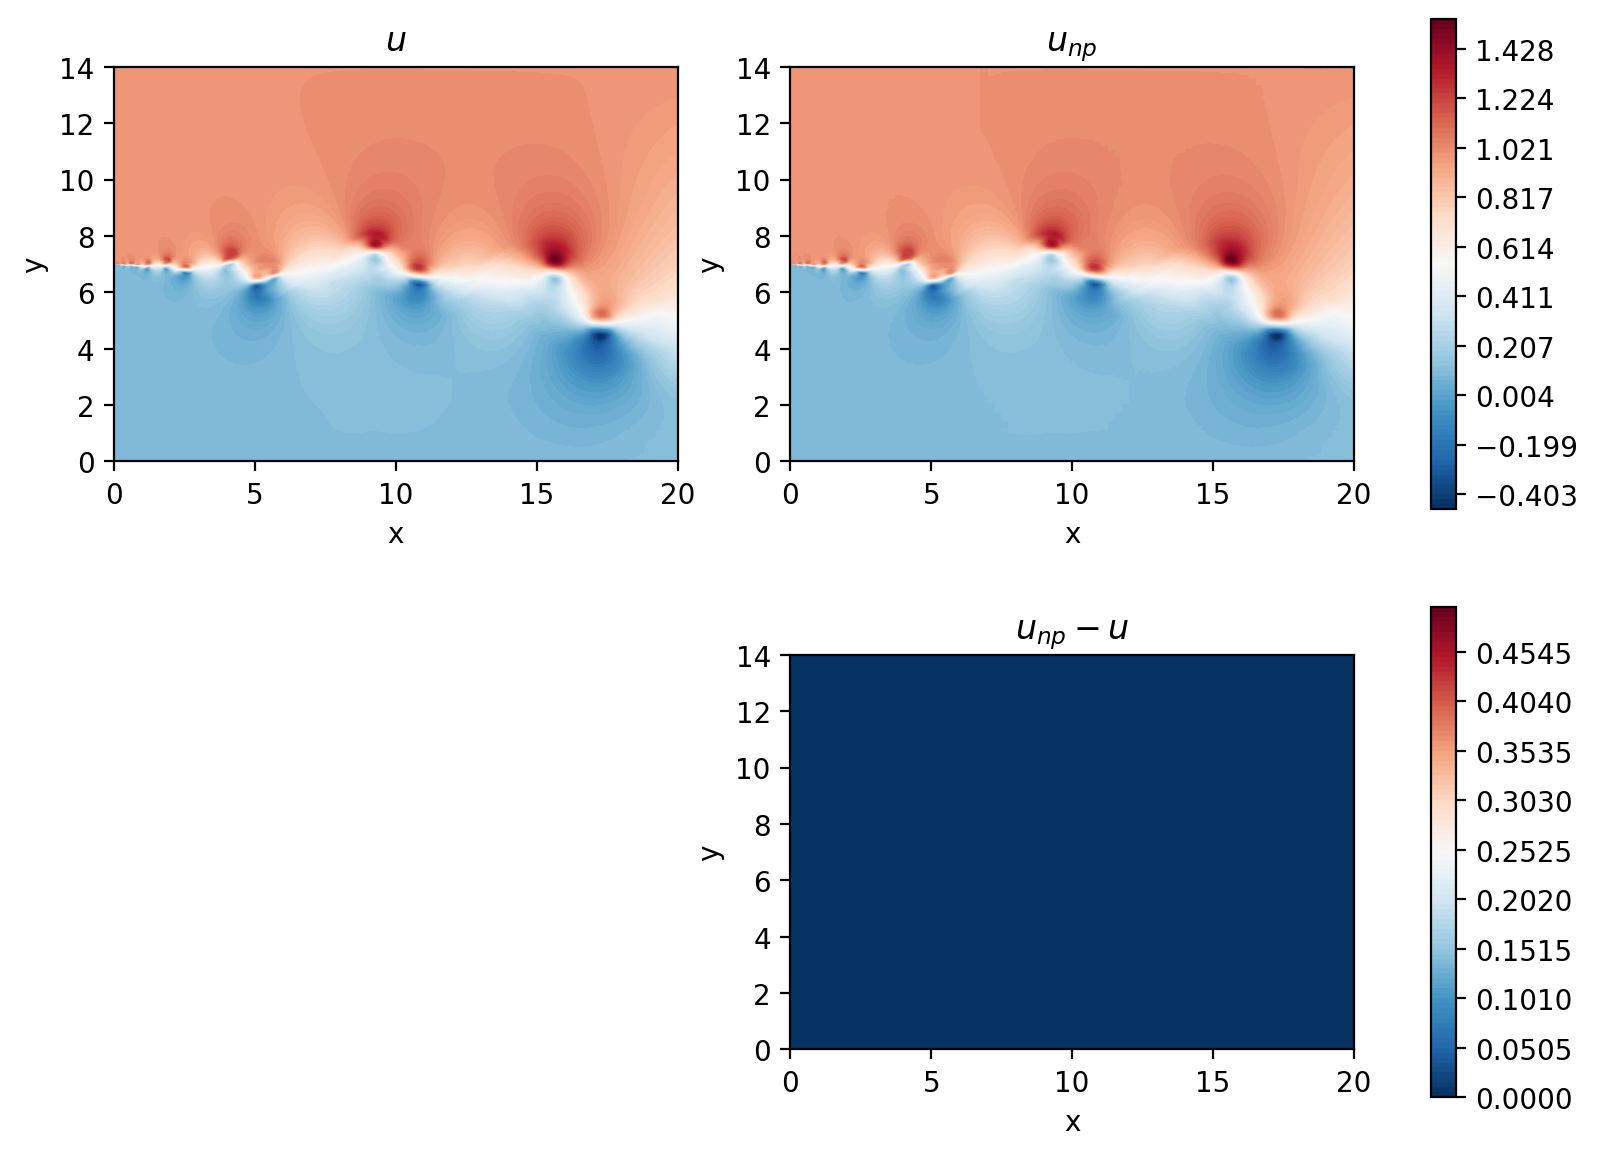

In [11]:


fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 7), dpi = 200)

c00 = ax[0,0].tricontourf(msh.x.flatten(), msh.y.flatten() ,fld.registry["u"].flatten(), levels=u_levels, cmap="RdBu_r")
ax[0,0].set_aspect('equal')
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].set_title(r"$u$")

c01 = ax[0,1].tricontourf(msh.x.flatten(), msh.y.flatten() ,u_np.flatten(), levels=u_levels, cmap="RdBu_r")
ax[0,1].set_aspect('equal')
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("y")
ax[0,1].set_title(r"$u_{np}$")

ax[1, 0].axis('off')

c11 = ax[1,1].tricontourf(msh.x.flatten(), msh.y.flatten() ,np.sqrt((u_np.flatten()- u.flatten())**2), levels=err_levels, cmap="RdBu_r")
ax[1,1].set_aspect('equal')
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("y")
ax[1,1].set_title(r"$u_{np} - u$")

cbar0=fig.colorbar(c00, ax=ax[0,:])
cbar11=fig.colorbar(c11, ax=ax[1,:])
plt.show()

## Test the derivative

In [12]:
# Initiate the mesh partitioning
from pysemtools.datatypes.msh_connectivity import MeshConnectivity

msh_conn = MeshConnectivity(comm, msh = msh, use_hashtable=True)

dudx = coef.dudxyz(u, coef.drdx, coef.dsdx)
dudy = coef.dudxyz(u, coef.drdy, coef.dsdy)

dudx_np = coef.dudxyz(u_np, coef.drdx, coef.dsdx)
dudy_np = coef.dudxyz(u_np, coef.drdy, coef.dsdy)

dudx_levels = np.linspace(-2.5, 3.1, 100)
dudy_levels = np.linspace(-4.6, 7.6, 100)

2026-08-04 21:01:17,923  MeshConnectivity      INFO      Initializing MeshConnectivity
2026-08-04 21:01:17,924  MeshConnectivity      INFO      Computing local connectivity
2026-08-04 21:01:18,037  MeshConnectivity      INFO      Computing global connectivity
2026-08-04 21:01:18,038  MeshConnectivity      INFO      Computing multiplicity
2026-08-04 21:01:18,047  MeshConnectivity      INFO      MeshConnectivity initialized
2026-08-04 21:01:18,047  MeshConnectivity      INFO      Elapsed time: 0.12300694800000045s


### Numpy

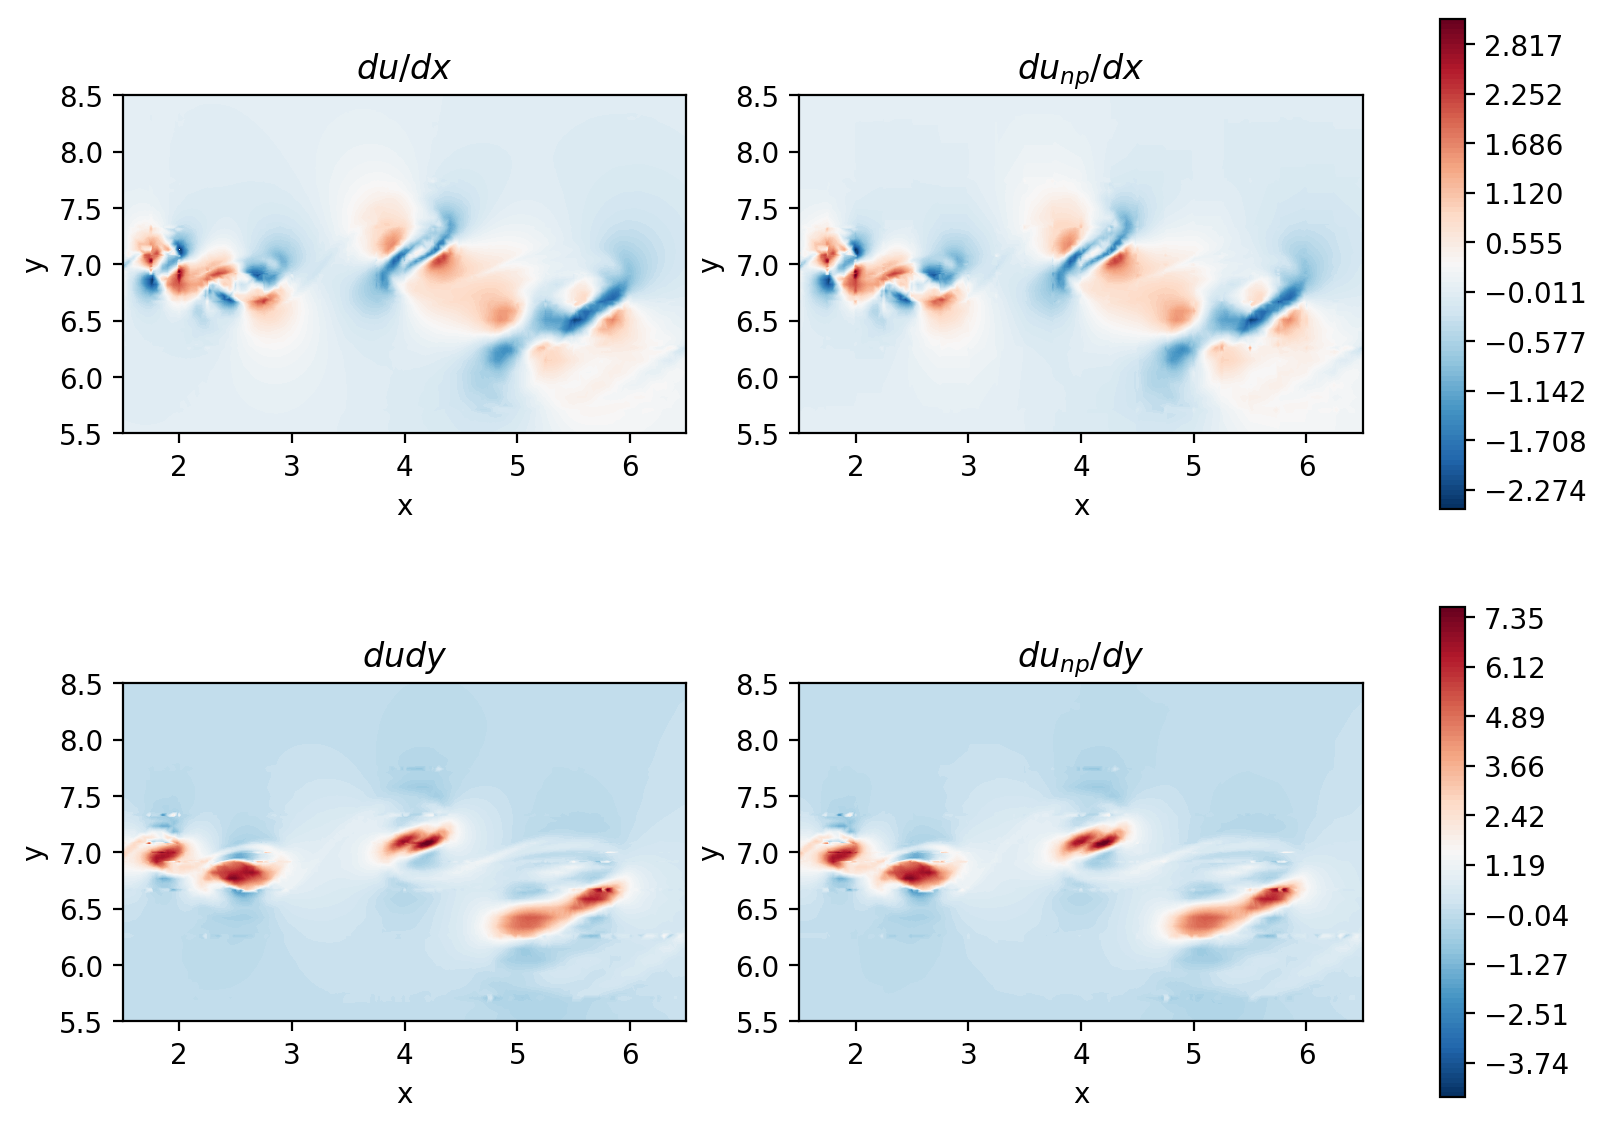

In [13]:

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 7), dpi = 200)

c00 = ax[0,0].tricontourf(msh.x.flatten(), msh.y.flatten() ,dudx.flatten(), levels=dudx_levels, cmap="RdBu_r")
ax[0,0].set_aspect('equal')
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].set_title(r"$du/dx$")

c01 = ax[0,1].tricontourf(msh.x.flatten(), msh.y.flatten() ,dudx_np.flatten(), levels=dudx_levels, cmap="RdBu_r")
ax[0,1].set_aspect('equal')
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("y")
ax[0,1].set_title(r"$du_{np}/dx$")

c10 = ax[1,0].tricontourf(msh.x.flatten(), msh.y.flatten() ,dudy.flatten(), levels=dudy_levels, cmap="RdBu_r")
ax[1,0].set_aspect('equal')
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("y")
ax[1,0].set_title(r"$dudy$")

c11 = ax[1,1].tricontourf(msh.x.flatten(), msh.y.flatten() ,dudy_np.flatten(), levels=dudy_levels, cmap="RdBu_r")
ax[1,1].set_aspect('equal')
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("y")
ax[1,1].set_title(r"$du_{np}/dy$")

cbar0=fig.colorbar(c00, ax=ax[0,:])
cbar10=fig.colorbar(c10, ax=ax[1,:])


ax[0,0].set_xlim([1.5,6.5])
ax[0,0].set_ylim([5.5,8.5])

ax[0,1].set_xlim([1.5,6.5])
ax[0,1].set_ylim([5.5,8.5])

ax[1,0].set_xlim([1.5,6.5])
ax[1,0].set_ylim([5.5,8.5])

ax[1,1].set_xlim([1.5,6.5])
ax[1,1].set_ylim([5.5,8.5])

plt.show()

## Metrics

Check reconstruction error against the fixed-error target.

In [14]:
# Reconstruction error arrays
err = u_np - u

# Unweighted RMS metrics in physical space
global_rms = np.sqrt(np.mean(err**2))
per_elem_rms = np.sqrt(np.mean(err.reshape(err.shape[0], -1)**2, axis=1))
mean_rms_per_elem = np.mean(per_elem_rms)

# Proper physical-space weighted RMS metrics use coef.B
B = coef.B
num_B = np.sum((err**2) * B, axis=(1, 2, 3))
den_B = np.sum(B, axis=(1, 2, 3))
weighted_rms_per_elem_B = np.sqrt(num_B / den_B)
mean_weighted_rms_per_elem_B = np.mean(weighted_rms_per_elem_B)

# Target/achieved values tracked by the sampler (spectral-space criterion)
target = dlt.settings["compression"].get("target_error", np.nan)
sampler_avg_achieved = dlt.settings["compression"].get("avg_achieved_error", np.nan)

print(f"target_error (input): {target:.3e}")
print(f"sampler avg achieved error (spectral weighted): {sampler_avg_achieved:.3e}")
print(f"mean weighted RMS error (physical, B-weighted): {mean_weighted_rms_per_elem_B:.3e}")
print(f"global RMS error (physical, unweighted): {global_rms:.3e}")
print(f"mean per-element RMS error (physical, unweighted): {mean_rms_per_elem:.3e}")

target_error (input): 1.000e-04
sampler avg achieved error (spectral weighted): 6.743e-05
mean weighted RMS error (physical, B-weighted): 2.697e-04
global RMS error (physical, unweighted): 5.181e-04
mean per-element RMS error (physical, unweighted): 4.584e-04
